In [24]:
from langgraph.graph import StateGraph, START, END
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from dotenv import load_dotenv
from typing import TypedDict
import os

load_dotenv()

True

In [ ]:
api_key = os.getenv("NVIDIA_API_KEY")

client = ChatNVIDIA(
  model="openai/gpt-oss-120b",
  api_key=api_key, 
  temperature=1,
  top_p=1,
  max_tokens=4096,
)


C:\Users\anish\AppData\Local\Temp\ipykernel_29828\908004504.py:3: DeprecationWarning: The 'max_tokens' parameter is deprecated and will be removed in a future version. Please use 'max_completion_tokens' instead.
  client = ChatNVIDIA(


In [26]:
# create a state

class LLMState(TypedDict):
    question: str
    answer: str


In [31]:
def llm_qa(state: LLMState) -> LLMState:
    # extract the question from the state
    question = state["question"]
    # form a prompt
    prompt = f"Answer the following question: {question}"
    # get the response from the LLM
    response = client.invoke(prompt)
    state["answer"] = response.content
    return state

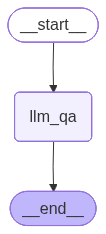

In [32]:
# create a graph
graph = StateGraph(LLMState)
# ADD NODES
graph.add_node("llm_qa", llm_qa)

# add edges
graph.add_edge(START, "llm_qa")
graph.add_edge("llm_qa", END)

# COMPILE THE GRAPH
graph.compile()


In [33]:
workflow = graph.compile()

In [34]:
# EXECUTE THE GRAPH
initial_state = {"question": "What is the capital of France?"}
final_state = workflow.invoke(initial_state)
print(final_state)  # {'question': 'What is the capital of France?', 'answer': 'The capital of France is Paris.'}
print(final_state['answer'])  # The capital of France is Paris.

{'question': 'What is the capital of France?', 'answer': 'The capital of France is **Paris**.'}
The capital of France is **Paris**.
